# 1 Imports Tools

In [ ]:
# Import necessary libraries
import pandas as pd  
import torch 
import numpy as np  
import torch.nn as nn  
import torch.optim as optim  

# Import Hugging Face Transformers library for model and tokenizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

# Import scikit-learn utilities for train-test split and evaluation metrics
from sklearn.model_selection import train_test_split  # Splits data into train and test sets
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, confusion_matrix  # Evaluation metrics

# Import PyTorch utilities for dataset handling
from torch.utils.data import Dataset, DataLoader  




# 2 Loading the Dataset

In [2]:
import pandas as pd

df = pd.read_csv("/content/product_reviews.csv", on_bad_lines="skip", engine="python")
df.head()


,Unnamed: 0,comment,stars
0,0,I could sit here and write all about the specs...,5
1,1,A very reasonably priced laptop for basic comp...,4
2,2,"This is the best laptop deal you can get, full...",5
3,3,A few months after the purchase....It is still...,5
4,4,BUYER BE AWARE: This computer has Microsoft 10...,1


In [3]:
df = df[['comment','stars']]
df = df.sample(n=5000, random_state=42).reset_index(drop=True)
df

,comment,stars
0,got this for my cousin and it works great!,5
1,Cannot provide location-based info. We could o...,1
2,Encantado con este gran título exclusivo de ni...,5
3,Small sturdy convenient and light weight,5
4,Got these anticipating the arrival of spring a...,5
...,...,...
4995,Great product. Fast shipping. A+,5
4996,This tripod was an excellent buy because it ha...,5
4997,[A],5
4998,Works great!,5


# 3 Cleaning Text

In [ ]:

import re  # Regular expressions for text processing
import string  # String operations
from nltk.corpus import stopwords  # Stopwords from NLTK corpus
from nltk.stem import PorterStemmer  # Porter Stemmer for word stemming
from nltk.tokenize import word_tokenize  # Tokenization from NLTK
df = df.sample(n=2000)




import nltk
nltk.download('stopwords')  
nltk.download('punkt')  
nltk.download('punkt_tab')


# Define a function to preprocess text
def preprocess_text(text):
    # Lowercase the text
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove emails
    text = re.sub(r'\S*@\S*\s?', '', text)

    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into a single string
    text = ' '.join(tokens)

    return text

# Apply preprocessing to the 'comment' column
df['cleaned_comment'] = df['comment'].apply(lambda x: preprocess_text(x))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
df.head()

,comment,stars,cleaned_comment
1761,"Everything should be prefaced with a ""okay for...",3,everyth prefac okay price warn saidim internet...
1373,I was doubtful when I purchased the antenna. H...,5,doubt purchas antenna howev ten minut instal t...
3375,The 8 ream paper is a good amount of paper at ...,5,ream paper good amount paper good valu without...
2321,I was pleased to see the recent Facebook inter...,5,pleas see recent facebook interfac appar ’ ava...
3872,"So light and so powerful, I couldn't ask for m...",5,light power couldnt ask sound qualiti decent b...


# 4 Label Encoding

In [6]:
def label_mapping(stars):
    """Convert star ratings into class labels (0-4)."""
    return stars - 1

df['labels'] = df['stars'].apply(label_mapping)


In [7]:
df

,comment,stars,cleaned_comment,labels
1761,"Everything should be prefaced with a ""okay for...",3,everyth prefac okay price warn saidim internet...,2
1373,I was doubtful when I purchased the antenna. H...,5,doubt purchas antenna howev ten minut instal t...,4
3375,The 8 ream paper is a good amount of paper at ...,5,ream paper good amount paper good valu without...,4
2321,I was pleased to see the recent Facebook inter...,5,pleas see recent facebook interfac appar ’ ava...,4
3872,"So light and so powerful, I couldn't ask for m...",5,light power couldnt ask sound qualiti decent b...,4
...,...,...,...,...
2117,"Feels way better than the joy con controller, ...",5,feel way better joy con control imo comfort,4
818,Received my antenna via Amazon very quickly. T...,5,receiv antenna via amazon quickli setup instru...,4
1243,"DON'T DO IT! These earbuds look great, the cas...",2,dont earbud look great case exquisit wireless ...,1
583,High quality product and very affordable! Tha...,5,high qualiti product afford thank amazon save ...,4


# Balancing Dataset

In [8]:
# Import necessary libraries
from imblearn.over_sampling import RandomOverSampler  # For handling imbalanced datasets
import pandas as pd  # For data manipulation

# Define features (comment text) and target labels
X = df[["comment", "cleaned_comment"]]  # Keep both original and cleaned text
y = df["labels"]  # Target labels for classification

# Initialize Random OverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)

# Apply oversampling to create a balanced dataset
X_resampled, y_resampled = ros.fit_resample(X, y)

# Convert the resampled data back into a DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=["comment", "cleaned_comment"])  # Preserve column names
df_balanced["labels"] = y_resampled  # Add balanced labels back

# Display the new class distribution to verify balancing
print(df_balanced["labels"].value_counts())  # Should show approximately equal counts for each class


labels
2    1383
4    1383
1    1383
3    1383
0    1383
Name: count, dtype: int64


# 5 Tokenization

In [ ]:
# Import tokenizer from Hugging Face Transformers library
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Function to tokenize the text data
def tokenize_data(batch):
   
    return tokenizer(batch["cleaned_comment"], padding="max_length", truncation=True, max_length=128)

# Dataset Class for PyTorch
class ReviewDataset(Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings  # Tokenized text data
        self.labels = labels  # Corresponding labels

    def __len__(self):
        """Returns the total number of samples."""
        return len(self.labels)

    def __getitem__(self, idx):
        
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}  # Convert tokenized text to tensors
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)  # Convert label to tensor
        return item

# Splitting the balanced dataset into Train, Validation, and Test sets
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_balanced['cleaned_comment'].tolist(),  # Convert DataFrame column to list
    df_balanced['labels'].tolist(),  # Convert labels to list
    test_size=0.2,  # 20% data reserved for validation & testing
    random_state=42  # Ensures reproducibility
)

# Further split temp_texts into validation and test sets (50-50 split)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

# Tokenizing the train, validation, and test text data
train_encodings = tokenizer(train_texts, padding=True, truncation=True, max_length=128)
val_encodings = tokenizer(val_texts, padding=True, truncation=True, max_length=128)
test_encodings = tokenizer(test_texts, padding=True, truncation=True, max_length=128)

# Creating PyTorch Datasets using the custom ReviewDataset class
train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

# Display dataset sizes
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Test Samples: {len(test_dataset)}")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training Samples: 5532
Validation Samples: 691
Test Samples: 692


# 6 Fine Tuning Model (Training)

In [19]:

# Model & Training Settings
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5)
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    logging_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Fine-tune Model
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.285400,0.295256
2,0.176200,0.093386
3,0.071700,0.136021
4,0.050700,0.114469
5,0.017200,0.041247


TrainOutput(global_step=1730, training_loss=0.2537544041010686, metrics={'train_runtime': 344.3327, 'train_samples_per_second': 80.329, 'train_steps_per_second': 5.024, 'total_flos': 916061069030400.0, 'train_loss': 0.2537544041010686, 'epoch': 5.0})

# Plot Training & Validation Loss per Epoch

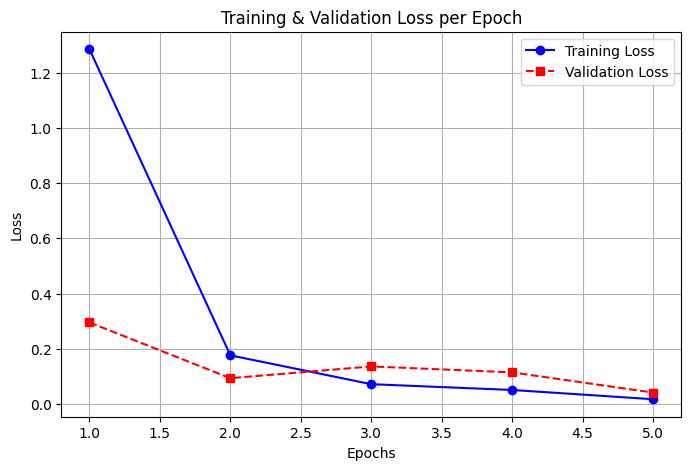

In [42]:
import matplotlib.pyplot as plt

# Data for plotting
epochs = [1, 2, 3, 4, 5]
train_loss = [1.285400, 0.176200, 0.071700, 0.050700, 0.017200]
val_loss = [0.295256, 0.093386, 0.136021, 0.114469, 0.041247]

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', linestyle='-', label="Training Loss", color="blue")
plt.plot(epochs, val_loss, marker='s', linestyle='--', label="Validation Loss", color="red")

# Labels and title
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss per Epoch")
plt.legend()
plt.grid()

# Show plot
plt.show()


# 7 Model Evaluation

  Evaluation Metrics:
MSE: 0.08959537572254335
MAE: 0.03468208092485549
RMSE: 0.2993248665288992

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       140
           1       1.00      1.00      1.00       142
           2       0.99      1.00      1.00       118
           3       0.94      0.99      0.97       155
           4       0.99      0.91      0.95       137

    accuracy                           0.98       692
   macro avg       0.98      0.98      0.98       692
weighted avg       0.98      0.98      0.98       692


  Confusion Matrix:


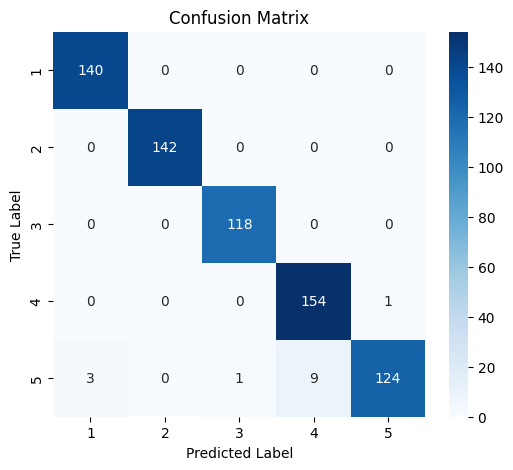

In [25]:
# Evaluate the model on the test dataset
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


preds_output = trainer.predict(test_dataset)  # Get model predictions
preds = np.argmax(preds_output.predictions, axis=1)  # Convert logits to class labels


# Function to calculate and print evaluation metrics
def print_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)  # Mean Squared Error
    mae = mean_absolute_error(y_true, y_pred)  # Mean Absolute Error
    rmse = np.sqrt(mse)  # Root Mean Squared Error

    print("  Evaluation Metrics:")
    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("\n Classification Report:")
    print(classification_report(y_true, y_pred))  # Precision, Recall, F1-score
    print("\n  Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    # Plot the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Print the evaluation results
print_metrics(test_labels, preds)

# 8 Save Train Model

In [ ]:
# Save Model
model.save_pretrained("./fine_tuned_transformer")
tokenizer.save_pretrained("./fine_tuned_transformer")

('./fine_tuned_transformer/tokenizer_config.json',
 './fine_tuned_transformer/special_tokens_map.json',
 './fine_tuned_transformer/vocab.txt',
 './fine_tuned_transformer/added_tokens.json',
 './fine_tuned_transformer/tokenizer.json')

# 9  Real-Time Prediction Function


In [ ]:
import torch
import torch.nn.functional as F

# Real-Time Prediction Function
def predict(text):
    text = preprocess_text(text)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {key: val.to("cuda") for key, val in inputs.items()}

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits  # Get logits

    probs = F.softmax(logits, dim=1)  # Convert logits to probabilities
    confidence, predicted_class = torch.max(probs, dim=1)  # Get highest probability and class index

    return predicted_class.item() + 1, confidence.item()  # Convert back to star rating & return confidence

# Example Usage
import random

# Select 20 random sentences from df_balanced['comment']
random_comments = random.sample(df_balanced['comment'].tolist(), 20)

# Predict and print results one by one
for i, comment in enumerate(random_comments, 1):
    predicted_class, confidence_score = predict(comment)
    print(f"{i}. Comment: {comment}")
    print(f"   Predicted Star: {predicted_class}, Confidence Score: {confidence_score:.4f}")
    print("-" * 80)  # Separator for readability



1. Comment: This is good to use while you sleep but while you are awake it’s not good only because it charge slow. From 17% to 76% in 5 hours.
   Predicted Star: 3, Confidence Score: 0.9996
--------------------------------------------------------------------------------
2. Comment: 👍🏻
   Predicted Star: 5, Confidence Score: 0.9918
--------------------------------------------------------------------------------
3. Comment: These are incredible quality for the price! Plug in a usb cord to the wall and hook up to wifi with the Wyze app, you're all set! I activated with Alexa and can ask her to show the cam on my fire tv! Ordered a 2nd within an hour of the first one arriving, getting the whole system of bulbs and sensors next!If you're concerned about privacy, connect it to your guest network and give it a unique password. If someone gains physical access to your cam, they could sync it to their device to spy on you- take precautions. If you're wanting airtight security, you probably don'